In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("car data.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [37]:
# Shape
df.shape

# Data types
df.dtypes

# Missing values
df.isnull().sum()

# Duplicates
df.duplicated().sum()

# Remove duplicates
df = df.drop_duplicates()

# Summary statistics
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [38]:
current_year = 2026
df["car_age"] = current_year - df["year"]

In [39]:
df["brand"] = df["name"].str.split().str[0]

In [40]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


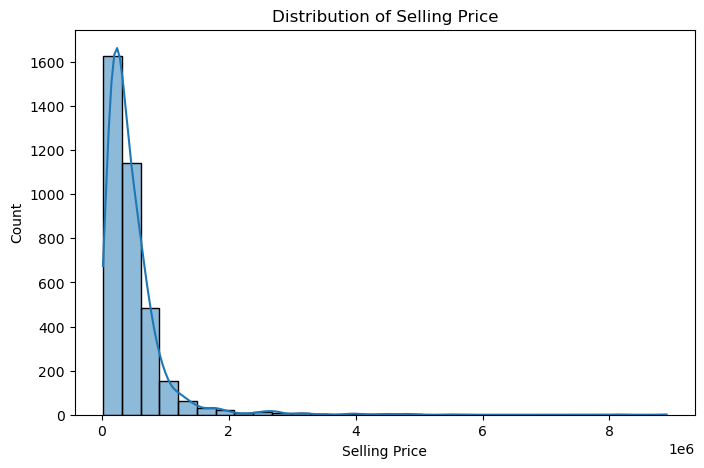

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.show()

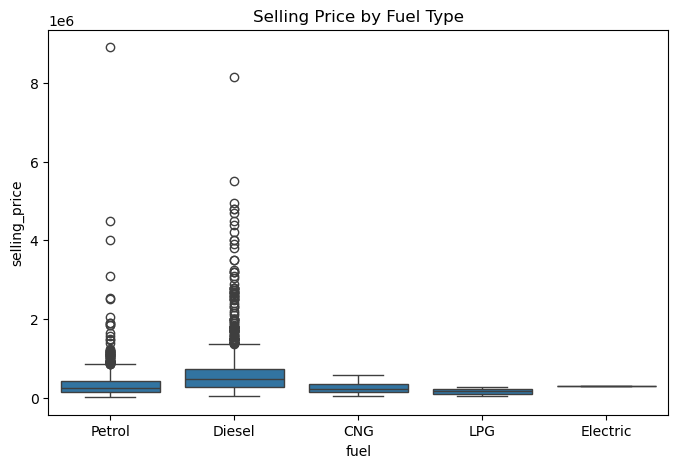

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(x="fuel",
            y="selling_price",
            data=df)

plt.title("Selling Price by Fuel Type")

plt.show()

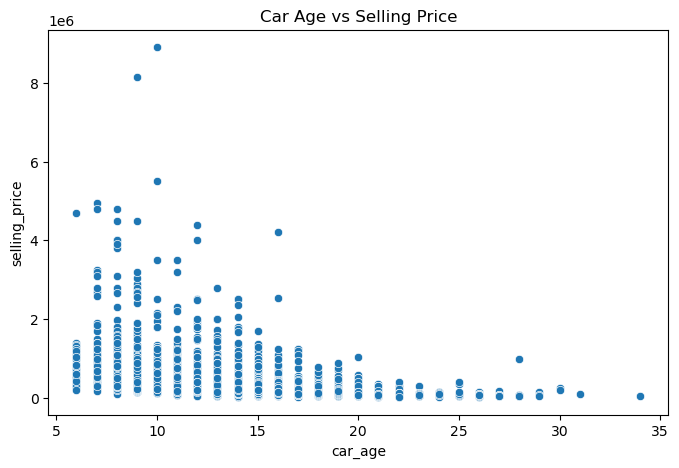

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="car_age",
                y="selling_price",
                data=df)

plt.title("Car Age vs Selling Price")

plt.show()

In [44]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for column in ["fuel","seller_type","transmission","owner","brand"]:
    df[column] = encoder.fit_transform(df[column])

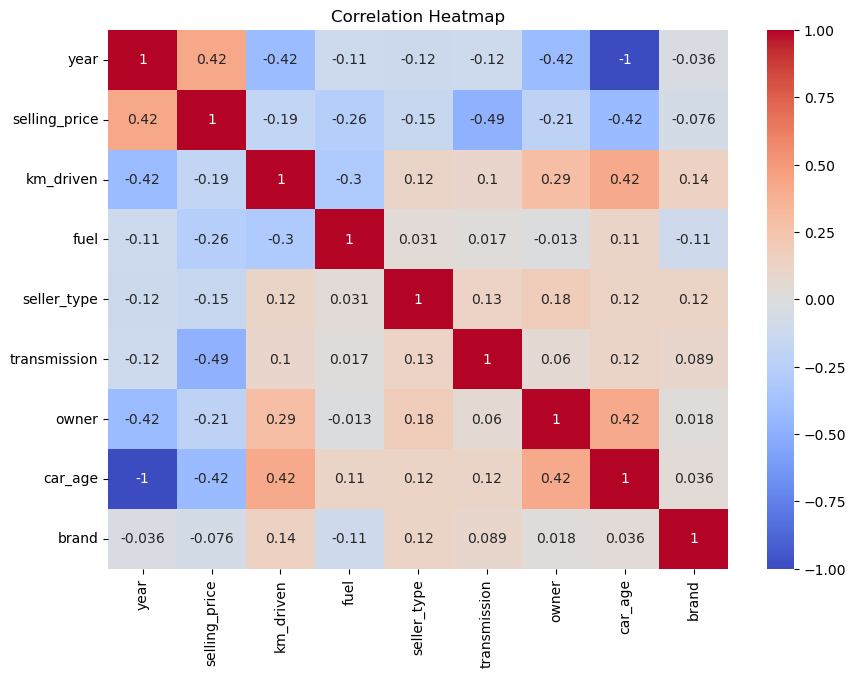

In [45]:
plt.figure(figsize=(10,7))

sns.heatmap(df.drop("name",axis=1).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [46]:
X = df.drop(["selling_price","name","year"], axis=1)

y = df["selling_price"]

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, pred_lr))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_lr)))

print("R2 Score :", r2_score(y_test, pred_lr))

Linear Regression
MAE : 214459.00488101112
RMSE : 444901.42936270934
R2 Score : 0.3855424187374996


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [51]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, pred_rf))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_rf)))

print("R2 Score :", r2_score(y_test, pred_rf))

Random Forest
MAE : 167745.03450032067
RMSE : 410066.6518975825
R2 Score : 0.477996746842939


In [52]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_rf))
    ],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,214459.004881,444901.429363,0.385542
1,Random Forest,167745.034500,410066.651898,0.477997


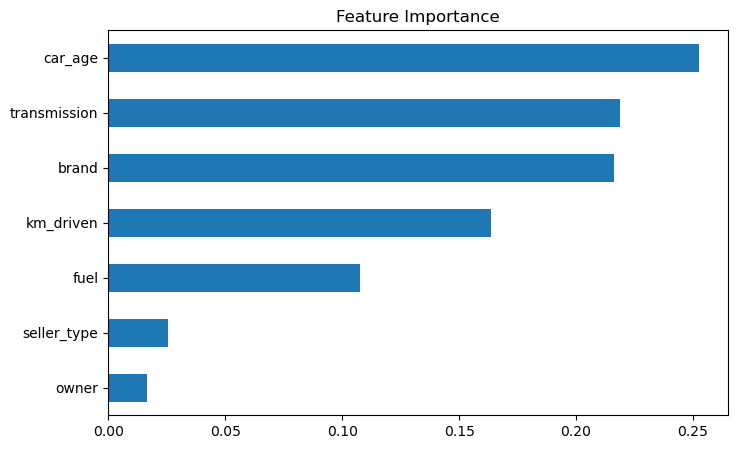

In [53]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance")

plt.show()